# Notebook 4 — Feature Engineering

**Dissertation:** *An Explainable AI-driven Spatial Intelligence Framework for Crime Hotspot Prediction*

Notebook 3 fixed the spatial substrate: a 250 m grid over the City of London and an empirically-derived, temporally-stable definition of a hotspot cell. This notebook turns that substrate into the **modelling table** — one row per cell per month — on which the interpretable models of Notebook 5 are trained. The task is to design a *small, non-redundant, and fully justified* set of predictors, because the framework's guiding principle is explainability, and an explanation is only as trustworthy as the features it is built from.

The design follows Section 5 of the approved Project Design Document exactly, and obeys two hard rules throughout:

1. **No leakage.** Every feature for a target month *t* is computed using information available *only up to and including month t−1*. The hotspot label being predicted is defined within its own month and never leaks backward into the features.
2. **Interpretability first.** Every feature must be (i) traceable to the uploaded literature or the official police.uk dataset documentation, (ii) purposeful for spatial crime-risk prediction, and (iii) directly readable in a later SHAP attribution. Any feature that fails these tests, or that merely duplicates another, is removed — the notebook shows the evidence for each removal rather than asserting it.

Features fall into three groups: **temporal-historical** (a cell's own recent past), **spatial-neighbourhood** (what happened next door), and **contextual** (the built environment from OpenStreetMap). Each group is motivated, computed, pruned, and documented in turn, and the notebook closes with a feature dictionary that states, for every retained variable, its calculation, its literature justification, and how it will contribute to the SHAP-based explanation.


## 1. Setup and Inputs

The notebook consumes only the artefacts written by Notebooks 1–3: the crime records already mapped to grid cells, and the grid/projection parameters that guarantee the identical tessellation is reproduced. No new external information is introduced except the OpenStreetMap contextual layer of Section 4, whose extraction is fully documented and cached.


In [1]:
from pathlib import Path
import os, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
NAVY = "#2E5496"; CRIMSON = "#B03A3A"; GOLD = "#C8912B"

DATA_DIR = Path(os.environ.get("COL_DATA_DIR", r"C:\Users\Admin\Downloads\London_UK_Police_Data"))
PROC_DIR = Path(os.environ.get("COL_OUTPUT_DIR", str(DATA_DIR / "processed")))

crimes = pd.read_csv(PROC_DIR / "crimes_with_grid250.csv", parse_dates=["month"])
params = pd.read_csv(PROC_DIR / "grid_250m_params.csv").iloc[0]
grid_tbl = pd.read_csv(PROC_DIR / "grid_250m_hotspots.csv")

NCOL = int(params["ncol"]); NROW = int(params["nrow"]); SIZE = int(params["cell_size_m"])
X0 = float(params["x0"]); Y0 = float(params["y0"])
LON0 = float(params["lon0"]); LAT0 = float(params["lat0"]); R = float(params["earth_radius_m"])
COSLAT = math.cos(math.radians(LAT0))
HOT_PCT = int(params["hotspot_percentile"])
CELLS = list(range(NROW * NCOL))

crimes["ym"] = crimes["month"].dt.to_period("M")
MONTHS = sorted(crimes["ym"].unique())
print(f"Crime records: {len(crimes):,}  |  grid: {NROW}x{NCOL} = {len(CELLS)} cells  |  months: {len(MONTHS)}")
print(f"Hotspot rule inherited from NB3: within-month top {100-HOT_PCT}% (P{HOT_PCT}) of occupied cells")

def to_lonlat(x, y):
    return (LON0 + np.degrees(np.asarray(x)/(R*COSLAT)), LAT0 + np.degrees(np.asarray(y)/R))
def to_metres(lon, lat):
    return (np.radians(np.asarray(lon)-LON0)*R*COSLAT, np.radians(np.asarray(lat)-LAT0)*R)
def cell_centroid(cid):
    ci, ri = cid % NCOL, cid // NCOL
    return X0 + (ci+0.5)*SIZE, Y0 + (ri+0.5)*SIZE


Crime records: 8,435  |  grid: 7x12 = 84 cells  |  months: 13
Hotspot rule inherited from NB3: within-month top 20% (P80) of occupied cells


## 2. The Cell–Month Panel and the Prediction Target

The unit of prediction is the **cell-month**: for each 250 m cell and each month, will that cell be a hotspot? The panel therefore has one row per (cell, month). All {ncells} cells of the tessellation are retained — including those that are usually empty — because in a risk model a quiet cell is a genuine low-risk observation, and discarding it would bias the target toward busy areas (the point argued in Notebook 3).

**Target definition (leakage-safe).** The label for a cell in month *t* is set by the *same empirical rule adopted in Notebook 3, applied within month t*: a cell is a hotspot if its crime count that month is at or above the 80th percentile of the occupied cells that month. Defining the threshold inside each month is deliberate — it is the quantity the model is asked to predict, it adapts to each month's overall level, and because it is computed only from month *t* it cannot leak into the features, which are all drawn from months before *t*.


In [2]:
# Monthly count matrix: cells x months (structural zeros preserved)
cm = (crimes.groupby(["cell250", "ym"]).size().unstack(fill_value=0)
      .reindex(index=CELLS, columns=MONTHS, fill_value=0))

def within_month_label(col):
    occ = col[col > 0]
    if len(occ) == 0:
        return (col * 0).astype(int)
    thr = np.percentile(occ.values, HOT_PCT)
    return (col >= thr).astype(int)

label = cm.apply(within_month_label, axis=0)   # cells x months, 0/1
print("Hotspot cells identified per month (within-month P80):")
print(pd.DataFrame({"month":[str(m) for m in MONTHS], "hotspots":label.sum(axis=0).values,
                    "occupied":(cm>0).sum(axis=0).values}).to_string(index=False))
print(f"\nMean hotspots/month: {label.sum(axis=0).mean():.1f}  "
      f"-> a persistently small minority class, as expected.")


Hotspot cells identified per month (within-month P80):
  month  hotspots  occupied
2025-01        11        52
2025-02        12        51
2025-03        12        53
2025-04        13        52
2025-05        11        52
2025-06        11        53
2025-07        10        50
2025-08        11        52
2025-09        13        50
2025-10        11        53
2025-11        11        51
2025-12        11        52
2026-01        12        53

Mean hotspots/month: 11.5  -> a persistently small minority class, as expected.


## 3. Temporal-Historical Features — a Cell's Own Recent Past

The strongest and best-evidenced predictor of crime in a place is its own recent history. The **near-repeat** phenomenon — that a location which has just been victimised is at elevated risk in the near future — is documented directly in the uploaded literature (Ratcliffe, 2005) and underpins the predictability of hotspots reported by Chainey, Tompson and Uhlig (2008). Temporal-historical features encode this memory. Because they are the features most likely to be collinear, they are also where the *avoid-redundancy* discipline bites hardest, so a deliberately generous set of candidates is computed first and then pruned on evidence.

Candidates (all computed from months strictly before the target month *t*):

- `lag1_count` — crime count in *t−1* (the immediate near-repeat signal);
- `lag2_count` — crime count in *t−2* (slightly longer memory);
- `roll3_mean` — mean monthly count over the previous three months (a smoothed recent *level*, robust to a one-off spike);
- `trend_1` — the change from *t−2* to *t−1* (short-term *momentum*: is the cell heating up or cooling down?);
- `prior_hotspot_freq` — the fraction of all prior months in which the cell was itself a hotspot (long-run *chronicity*, i.e. hotspot stability in the sense of Chainey et al., 2008).


In [3]:
# Queen-contiguity neighbours (used in Section 4 too)
def neighbours(cid):
    ci, ri = cid % NCOL, cid // NCOL; out = []
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0: continue
            r, c = ri+dr, ci+dc
            if 0 <= r < NROW and 0 <= c < NCOL: out.append(r*NCOL + c)
    return out
NB = {c: neighbours(c) for c in CELLS}

rows = []
for ti in range(1, len(MONTHS)):        # target months 2..13 (need >= 1 lag)
    t = MONTHS[ti]; prev = MONTHS[:ti]
    m1, m2 = MONTHS[ti-1], (MONTHS[ti-2] if ti >= 2 else None)
    for c in CELLS:
        lag1 = int(cm.loc[c, m1])
        lag2 = int(cm.loc[c, m2]) if m2 is not None else np.nan
        roll3 = float(cm.loc[c, MONTHS[max(0, ti-3):ti]].mean())
        trend = (lag1 - lag2) if m2 is not None else np.nan
        phf = float(label.loc[c, prev].mean())
        neigh_sum = int(cm.loc[NB[c], m1].sum())
        neigh_hs = float(label.loc[NB[c], m1].mean())
        rows.append(dict(cell=c, month=str(t), y=int(label.loc[c, t]),
                         lag1_count=lag1, lag2_count=lag2, roll3_mean=round(roll3, 3),
                         trend_1=trend, prior_hotspot_freq=round(phf, 3),
                         neigh_lag1_sum=neigh_sum, neigh_hotspot_share=round(neigh_hs, 3)))
panel = pd.DataFrame(rows)
# first target month has no t-2: drop rows lacking lag2/trend so the table is complete-case
panel = panel.dropna(subset=["lag2_count", "trend_1"]).reset_index(drop=True)
panel["lag2_count"] = panel["lag2_count"].astype(int); panel["trend_1"] = panel["trend_1"].astype(int)
print(f"Panel: {panel.shape[0]} rows (cell-months) x {panel.shape[1]} cols")
print(f"Target months retained: {panel['month'].nunique()} (from {panel['month'].min()} to {panel['month'].max()})")
print(f"Hotspot prevalence in panel: {100*panel['y'].mean():.1f}%  (minority class)")


Panel: 924 rows (cell-months) x 10 cols
Target months retained: 11 (from 2025-03 to 2026-01)
Hotspot prevalence in panel: 13.6%  (minority class)


### 3.1 Pruning Redundant Temporal Features

Keeping variables that carry the same information would inflate the model, split SHAP credit between duplicates, and make the explanation harder to read — the opposite of the framework's aim. The candidate features are therefore screened on two criteria: their association with the target (usefulness), and their mutual correlation (redundancy).


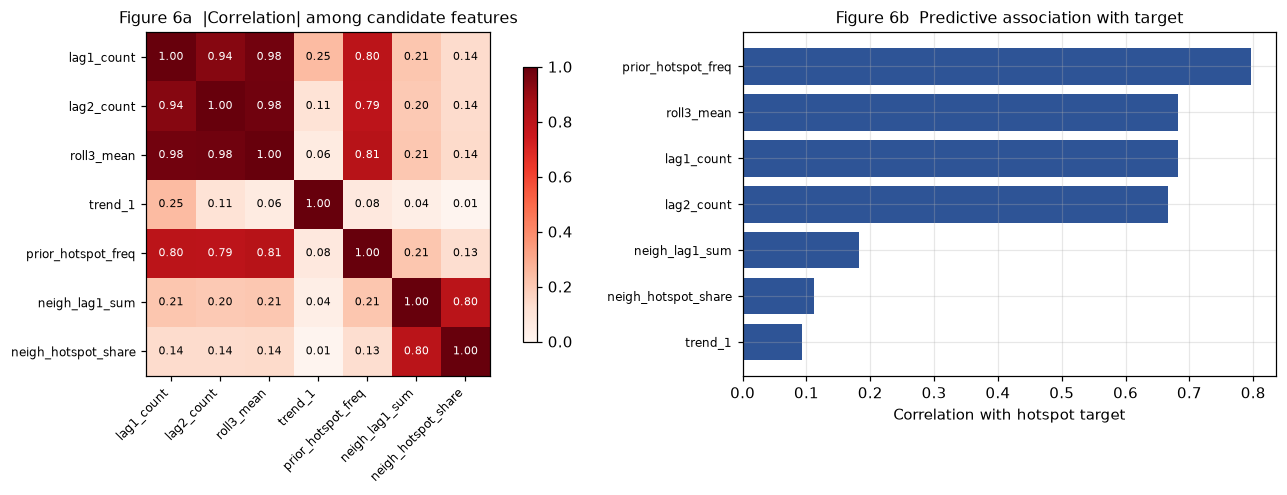

Evidence:
  level features lag1/lag2/roll3 are mutually collinear (|r| = 0.94-0.98) -> they carry one signal, not three.
  neigh_lag1_sum and neigh_hotspot_share overlap (|r| = 0.80).


In [4]:
cand = ["lag1_count","lag2_count","roll3_mean","trend_1","prior_hotspot_freq",
        "neigh_lag1_sum","neigh_hotspot_share"]
corr = panel[cand].corr()
tcorr = panel[cand + ["y"]].corr()["y"][cand]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6),
                             gridspec_kw={"width_ratios":[1.25, 1]})
im = a1.imshow(corr.abs().values, cmap="Reds", vmin=0, vmax=1)
a1.set_xticks(range(len(cand))); a1.set_xticklabels(cand, rotation=45, ha="right", fontsize=8)
a1.set_yticks(range(len(cand))); a1.set_yticklabels(cand, fontsize=8)
for i in range(len(cand)):
    for j in range(len(cand)):
        a1.text(j, i, f"{corr.abs().values[i,j]:.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if corr.abs().values[i,j]>0.6 else "black")
a1.set_title("Figure 6a  |Correlation| among candidate features", fontsize=10.5); a1.grid(False)
fig.colorbar(im, ax=a1, shrink=0.8)

order = tcorr.abs().sort_values().index
a2.barh(range(len(order)), tcorr[order].values, color=NAVY)
a2.set_yticks(range(len(order))); a2.set_yticklabels(order, fontsize=8)
a2.set_xlabel("Correlation with hotspot target")
a2.set_title("Figure 6b  Predictive association with target", fontsize=10.5)
plt.tight_layout(); plt.show()

print("Evidence:")
print(f"  level features lag1/lag2/roll3 are mutually collinear "
      f"(|r| = {corr.loc['lag1_count','lag2_count']:.2f}-{corr.loc['roll3_mean','lag1_count']:.2f})"
      f" -> they carry one signal, not three.")
print(f"  neigh_lag1_sum and neigh_hotspot_share overlap (|r| = "
      f"{corr.loc['neigh_lag1_sum','neigh_hotspot_share']:.2f}).")


**Decision, on the evidence above.** The three *level* candidates — `lag1_count`, `lag2_count`, `roll3_mean` — are near-collinear (|r| ≈ 0.94–0.98): they are three expressions of one underlying quantity, the cell's recent crime level. Retaining all three would triple-count that signal and fragment its SHAP attribution across interchangeable columns. A single representative is kept — **`roll3_mean`**, because a three-month average is more stable than a single lagged month and is the standard "recent level" construct in the hotspot-forecasting literature. `lag1_count` and `lag2_count` are therefore dropped as *features* (though `lag2` is still used, internally, to derive momentum).

The two remaining temporal candidates survive because each carries information the level feature does not: **`trend_1`** (momentum) is almost uncorrelated with level (|r| ≈ 0.06–0.25) yet encodes direction of change, and **`prior_hotspot_freq`** captures long-run *chronicity* — whether a cell is habitually rather than momentarily hot — which is conceptually distinct from its latest count and is, in fact, the single strongest correlate of the target. The retained temporal set is thus **`roll3_mean`, `trend_1`, `prior_hotspot_freq`** — three features, no duplication.


## 4. Spatial-Neighbourhood Features — What Happened Next Door

Crime risk diffuses across space: the near-repeat effect extends to the immediate surroundings of a victimised location, so that a cell's risk depends not only on its own past but on its neighbours' (Ratcliffe, 2005; Chainey et al., 2008). This is captured with a **spatial lag** — the total crime in the eight queen-contiguous neighbour cells in the previous month, `neigh_lag1_sum`.

A second candidate, `neigh_hotspot_share` (the fraction of neighbours that were hotspots last month), was computed but is **dropped**: as Figure 6a shows it is strongly correlated with `neigh_lag1_sum` (|r| ≈ 0.80), so it largely restates the same neighbourhood signal. Keeping the single continuous spatial lag preserves the diffusion construct with no redundancy and yields one clean, mappable SHAP contribution for "neighbourhood pressure". Edge cells simply have fewer neighbours, which the sum handles naturally without special-casing.


In [5]:
RETAINED_TEMPORAL = ["roll3_mean", "trend_1", "prior_hotspot_freq"]
RETAINED_SPATIAL   = ["neigh_lag1_sum"]
DROPPED = {"lag1_count":"collinear with roll3_mean (|r|~0.98)",
           "lag2_count":"collinear with roll3_mean (|r|~0.98); used only to derive trend_1",
           "neigh_hotspot_share":"redundant with neigh_lag1_sum (|r|~0.80)"}
print("Retained (temporal):", RETAINED_TEMPORAL)
print("Retained (spatial): ", RETAINED_SPATIAL)
print("Dropped for redundancy:")
for k, v in DROPPED.items(): print(f"   - {k}: {v}")
panel_core = panel.drop(columns=[c for c in DROPPED]).copy()
print("\nCore panel columns:", list(panel_core.columns))


Retained (temporal): ['roll3_mean', 'trend_1', 'prior_hotspot_freq']
Retained (spatial):  ['neigh_lag1_sum']
Dropped for redundancy:
   - lag1_count: collinear with roll3_mean (|r|~0.98)
   - lag2_count: collinear with roll3_mean (|r|~0.98); used only to derive trend_1
   - neigh_hotspot_share: redundant with neigh_lag1_sum (|r|~0.80)

Core panel columns: ['cell', 'month', 'y', 'roll3_mean', 'trend_1', 'prior_hotspot_freq', 'neigh_lag1_sum']


## 5. Contextual Features — the Built Environment from OpenStreetMap

Temporal and spatial features tell the model *where crime has been*; contextual features tell it *why a place is criminogenic*, and are what allow a SHAP explanation to point at something an analyst can act on ("this cell is high-risk partly because of its density of licensed premises") rather than only at the cell's own history. Following Section 5 of the Project Design Document, the contextual layer is **deliberately restricted** to built-environment variables that have explicit support in the reviewed literature and a clear criminogenic interpretation under routine-activity theory. Nothing is included that cannot be tied to a source and read in a SHAP plot.

Five static, per-cell contextual features are defined, each mapped to its justification:

| Feature | OpenStreetMap definition | Criminogenic mechanism | Literature |
|---|---|---|---|
| `osm_retail_density` | count of `shop=*` nodes per km² | retail concentrations are *crime attractors/generators* (footfall, goods, acquisitive crime) | Zhang et al. (2020) |
| `osm_food_drink_density` | `amenity∈{restaurant,cafe,fast_food}` per km² | eating places raise ambient population and guardianship dynamics (routine activity) | Zhang et al. (2022) |
| `osm_licensed_count` | `amenity∈{pub,bar,nightclub}` in-cell count | alcohol outlets are strongly associated with violence and public-order crime | Zhang et al. (2020, 2022) |
| `osm_transport_nodes` | rail/tube stations, subway entrances, `highway=bus_stop` in-cell count | transit nodes concentrate transient population and offender mobility | Zhang et al. (2020) |
| `osm_road_density_m` | total `highway` length (m) per cell | street permeability/accessibility shapes offender movement and opportunity | Zhang et al. (2022) |

These operationalise the built-environment covariates Zhang et al. (2020) show improve crime prediction and the routine-activity constructs underlying Zhang et al. (2022). The categories are intentionally **disjoint** — retail, food-and-drink, and licensed premises are separated so that a SHAP plot can distinguish the effect of shops from that of pubs — and the set is limited to five variables to keep the built-environment signal legible.


### 5.1 Reproducible OpenStreetMap Extraction

OpenStreetMap is an external source, so it is treated exactly as external context should be in reproducible research: extracted **once** with a documented query, **cached** to disk as GeoJSON, and read from the cache thereafter. The loader below parses the GeoJSON exported directly from *overpass-turbo* — no format conversion is required.

**Geographic extent.** The City-of-London bounding box, padded slightly so edge cells are not under-counted: **south=51.5073, west=−0.1140, north=51.5241, east=−0.0721** (this encloses the crime extent measured in Notebook 3).

**Query 1 — POIs (retail, food & drink, licensed premises, transport nodes).** Paste into [overpass-turbo.eu](https://overpass-turbo.eu), *Run*, then *Export → data → GeoJSON*:

```overpassql
[out:json][timeout:120];
(
  node["shop"](51.5073,-0.1140,51.5241,-0.0721);
  node["amenity"~"^(restaurant|cafe|fast_food|pub|bar|nightclub)$"](51.5073,-0.1140,51.5241,-0.0721);
  node["railway"~"^(station|subway_entrance)$"](51.5073,-0.1140,51.5241,-0.0721);
  node["highway"="bus_stop"](51.5073,-0.1140,51.5241,-0.0721);
);
out center;
```

**Query 2 — road network (for road-density).** Run separately, then *Export → data → GeoJSON*:

```overpassql
[out:json][timeout:120];
(way["highway"](51.5073,-0.1140,51.5241,-0.0721););
out geom;
```

**Required files and location.** Save the two exports with these exact names into the **`processed/`** folder beside the other cached files (the loader also checks the main data folder as a fallback):

```
London_UK_Police_Data/
└── processed/
    ├── osm_poi_col.geojson      ← export of Query 1
    └── osm_roads_col.geojson    ← export of Query 2
```

The loader assigns each POI to a grid cell with the **same projection and grid** used for crime points, derives the disjoint category from the OSM tags, and computes road length by summing highway segments per cell. If the files are not yet present the notebook does not fail: it creates the five columns as placeholders and remains ready to populate them on the next run, with no code change. (A legacy CSV format — `osm_points_col.csv` / `osm_roads_col.csv` — is also accepted.)


In [6]:
import json

def _assign_cell(lon, lat):
    x, y = to_metres(lon, lat)
    ci = int((x - X0) // SIZE); ri = int((y - Y0) // SIZE)
    return ri * NCOL + ci if (0 <= ci < NCOL and 0 <= ri < NROW) else -1

CELL_KM2 = (SIZE / 1000.0) ** 2   # 0.0625 km^2 for a 250 m cell

def _categorise(props):
    """Map OSM tags to one disjoint contextual category (priority: retail>food>licensed>transport)."""
    amen = props.get("amenity")
    if props.get("shop"):                              return "retail"
    if amen in {"restaurant", "cafe", "fast_food"}:    return "food_drink"
    if amen in {"pub", "bar", "nightclub"}:            return "licensed"
    if props.get("railway") in {"station", "subway_entrance"} or props.get("highway") == "bus_stop":
        return "transport"
    return None

def _find(*names):
    for n in names:
        for base in (PROC_DIR, DATA_DIR):
            p = base / n
            if p.exists(): return p
    return None

def load_osm_points():
    """Return DataFrame(lon, lat, category) from GeoJSON (preferred) or legacy CSV."""
    gj = _find("osm_poi_col.geojson")
    if gj is not None:
        feats = json.load(open(gj, encoding="utf-8")).get("features", [])
        rows = []
        for f in feats:
            geom = f.get("geometry") or {}
            props = f.get("properties", {})
            cat = _categorise(props)
            if cat is None: continue
            if geom.get("type") == "Point":
                lon, lat = geom["coordinates"][:2]
            elif "center" in f:                       # 'out center' fallback
                lat, lon = f["center"]["lat"], f["center"]["lon"]
            else: continue
            rows.append((lon, lat, cat))
        return pd.DataFrame(rows, columns=["lon", "lat", "category"]), str(gj.name)
    csv = _find("osm_points_col.csv")
    if csv is not None:
        return pd.read_csv(csv)[["lon","lat","category"]], str(csv.name)
    return None, None

def _iter_lines(geom):
    t = geom.get("type")
    if t == "LineString":       yield geom["coordinates"]
    elif t == "MultiLineString":
        for ln in geom["coordinates"]: yield ln

def load_osm_roads_length():
    """Return Series(cell -> total highway metres) from GeoJSON (preferred) or legacy CSV."""
    length = {c: 0.0 for c in CELLS}
    gj = _find("osm_roads_col.geojson")
    if gj is not None:
        feats = json.load(open(gj, encoding="utf-8")).get("features", [])
        for f in feats:
            for line in _iter_lines(f.get("geometry") or {}):
                for i in range(len(line) - 1):
                    (lon1, lat1), (lon2, lat2) = line[i][:2], line[i+1][:2]
                    x1, y1 = to_metres(lon1, lat1); x2, y2 = to_metres(lon2, lat2)
                    L = math.hypot(float(x2-x1), float(y2-y1))
                    c = _assign_cell(0.5*(lon1+lon2), 0.5*(lat1+lat2))
                    if c >= 0: length[c] += L
        return pd.Series(length, name="osm_road_density_m"), str(gj.name)
    csv = _find("osm_roads_col.csv")
    if csv is not None:
        rd = pd.read_csv(csv)
        for _, w in rd.groupby("way_id"):
            w = w.sort_values("seq"); lons = w["lon"].values; lats = w["lat"].values
            for i in range(len(w)-1):
                x1,y1 = to_metres(lons[i],lats[i]); x2,y2 = to_metres(lons[i+1],lats[i+1])
                L = math.hypot(float(x2-x1),float(y2-y1))
                c = _assign_cell(0.5*(lons[i]+lons[i+1]), 0.5*(lats[i]+lats[i+1]))
                if c >= 0: length[c] += L
        return pd.Series(length, name="osm_road_density_m"), str(csv.name)
    return None, None

def build_point_features(points_df):
    pts = points_df.copy()
    pts["cell"] = [_assign_cell(lo, la) for lo, la in zip(pts["lon"], pts["lat"])]
    pts = pts[pts["cell"] >= 0]
    g = pts.groupby(["cell", "category"]).size().unstack(fill_value=0)
    feat = pd.DataFrame(index=CELLS)
    feat["osm_retail_density"]     = g.get("retail", 0)     / CELL_KM2
    feat["osm_food_drink_density"] = g.get("food_drink", 0) / CELL_KM2
    feat["osm_licensed_count"]     = g.get("licensed", 0)
    feat["osm_transport_nodes"]    = g.get("transport", 0)
    return feat.reindex(CELLS).fillna(0.0)

OSM_COLS = ["osm_retail_density","osm_food_drink_density","osm_licensed_count",
            "osm_transport_nodes","osm_road_density_m"]

pts_df, pts_src = load_osm_points()
roads_len, roads_src = load_osm_roads_length()
if pts_df is not None and roads_len is not None:
    osm_feat = build_point_features(pts_df)
    osm_feat["osm_road_density_m"] = roads_len
    OSM_AVAILABLE = True
    print(f"OSM extract found (POI: {pts_src}, roads: {roads_src}).")
    print(f"  POIs categorised: {len(pts_df)}  |  cells with any POI: {(osm_feat[OSM_COLS[:4]].sum(axis=1)>0).sum()}")
    print(f"  total road length mapped: {osm_feat['osm_road_density_m'].sum():,.0f} m")
    display(osm_feat.loc[osm_feat.sum(axis=1).sort_values(ascending=False).index].head(6).round(1))
else:
    osm_feat = pd.DataFrame(index=CELLS, columns=OSM_COLS, dtype=float)   # placeholders
    OSM_AVAILABLE = False
    print("NOTE: OSM GeoJSON not present in 'processed/'. Five contextual columns created as")
    print("      placeholders (NaN); temporal + spatial features are fully real. Add")
    print("      osm_poi_col.geojson and osm_roads_col.geojson per Section 5.1 and re-run.")
osm_feat.index.name = "cell"


OSM extract found (POI: osm_poi_col.geojson, roads: osm_roads_col.geojson).
  POIs categorised: 1767  |  cells with any POI: 84
  total road length mapped: 368,615 m


,osm_retail_density,osm_food_drink_density,osm_licensed_count,osm_transport_nodes,osm_road_density_m
19,80.0,224.0,7,12,6752.1
31,512.0,208.0,9,13,6123.3
73,128.0,144.0,3,2,6541.3
64,112.0,64.0,1,7,6201.9
72,224.0,96.0,3,3,5800.7
56,384.0,400.0,1,13,5327.0


## 6. Assembling and Exporting the Modelling Table

The static contextual features are joined onto every cell-month row (they do not vary through time within this snapshot), producing the final modelling table — the sole deliverable consumed by Notebook 5.


In [7]:
model_tbl = panel_core.merge(osm_feat.reset_index(), on="cell", how="left")
FEATURES = RETAINED_TEMPORAL + RETAINED_SPATIAL + OSM_COLS
model_tbl = model_tbl[["cell","month","y"] + FEATURES]

cent = pd.DataFrame([dict(cell=c,
        centroid_lon=round(float(to_lonlat(*cell_centroid(c))[0]),6),
        centroid_lat=round(float(to_lonlat(*cell_centroid(c))[1]),6)) for c in CELLS])
model_tbl = model_tbl.merge(cent, on="cell", how="left")
model_tbl.to_csv(PROC_DIR / "model_table_250m.csv", index=False)

print(f"model_table_250m.csv written: {model_tbl.shape[0]} rows x {model_tbl.shape[1]} cols")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target prevalence: {100*model_tbl['y'].mean():.1f}%  |  OSM populated: {OSM_AVAILABLE}")
display(model_tbl.head(4))


model_table_250m.csv written: 924 rows x 14 cols
Features (9): ['roll3_mean', 'trend_1', 'prior_hotspot_freq', 'neigh_lag1_sum', 'osm_retail_density', 'osm_food_drink_density', 'osm_licensed_count', 'osm_transport_nodes', 'osm_road_density_m']
Target prevalence: 13.6%  |  OSM populated: True


,cell,month,y,roll3_mean,trend_1,prior_hotspot_freq,neigh_lag1_sum,osm_retail_density,osm_food_drink_density,osm_licensed_count,osm_transport_nodes,osm_road_density_m,centroid_lon,centroid_lat
0,0,2025-03,0,0.0,0,0.0,3,0.0,16.0,0,0,486.383290,-0.112683,51.508911
1,1,2025-03,0,0.0,0,0.0,5,224.0,112.0,0,0,1743.443685,-0.109070,51.508911
2,2,2025-03,0,0.0,0,0.0,9,0.0,32.0,2,2,2882.081028,-0.105458,51.508911
3,3,2025-03,0,0.0,0,0.0,8,64.0,16.0,0,2,1767.470553,-0.101845,51.508911


In [8]:
chk = model_tbl.groupby("month")["y"].agg(["mean","size"]).rename(columns={"mean":"hotspot_rate","size":"cells"})
print("Per-target-month summary (target defined within-month; features from prior months only):")
print(chk.assign(hotspot_rate=lambda d:(100*d.hotspot_rate).round(1)).to_string())


Per-target-month summary (target defined within-month; features from prior months only):
         hotspot_rate  cells
month                       
2025-03          14.3     84
2025-04          15.5     84
2025-05          13.1     84
2025-06          13.1     84
2025-07          11.9     84
2025-08          13.1     84
2025-09          15.5     84
2025-10          13.1     84
2025-11          13.1     84
2025-12          13.1     84
2026-01          14.3     84


## 7. Feature Dictionary — Calculation, Justification, and SHAP Role

The table below documents every retained feature: exactly how it is computed, the source that justifies it, and how it will read in the later SHAP analysis — the artefact that lets an examiner trace each model input back to the literature and forward to its explanation.


In [9]:
dictionary = [
 ("roll3_mean","temporal","Mean crime count in the cell over the previous 3 months (t-1..t-3)",
  "Near-repeat / hotspot persistence (Ratcliffe, 2005; Chainey et al., 2008)",
  "Smoothed recent level; expected large positive SHAP for chronically busy cells"),
 ("trend_1","temporal","Change in count from t-2 to t-1 (lag1 - lag2)",
  "Short-term momentum of the near-repeat process",
  "Separates heating-up from cooling-down cells at equal level; signed SHAP shows direction"),
 ("prior_hotspot_freq","temporal","Fraction of all prior months the cell was itself a hotspot",
  "Hotspot stability/chronicity (Chainey et al., 2008)",
  "Distinguishes habitual from occasional hotspots; strongest single correlate of target"),
 ("neigh_lag1_sum","spatial","Total crime in the 8 queen-contiguous neighbour cells in t-1",
  "Spatial diffusion of near-repeat risk (Ratcliffe, 2005; Chainey et al., 2008)",
  "Quantifies 'neighbourhood pressure'; mappable SHAP shows spillover into a cell"),
 ("osm_retail_density","contextual","Count of shop=* per km^2 in the cell",
  "Retail as crime attractor/generator (Zhang et al., 2020)",
  "Explains acquisitive-crime risk from land use, not history"),
 ("osm_food_drink_density","contextual","restaurant/cafe/fast_food per km^2 in the cell",
  "Routine-activity ambient population (Zhang et al., 2022)",
  "Attributes risk to footfall-generating land use"),
 ("osm_licensed_count","contextual","pub/bar/nightclub count in the cell",
  "Alcohol outlets & violence/public order (Zhang et al., 2020, 2022)",
  "Isolates alcohol-related contribution in the explanation"),
 ("osm_transport_nodes","contextual","Rail/tube/subway/bus nodes in the cell",
  "Transit nodes concentrate transient population/mobility (Zhang et al., 2020)",
  "Explains risk at accessibility hubs"),
 ("osm_road_density_m","contextual","Total highway length (m) within the cell",
  "Street permeability & offender movement (Zhang et al., 2022)",
  "Links accessibility of the street network to opportunity"),
]
feat_dict = pd.DataFrame(dictionary, columns=["feature","group","calculation","justification","shap_role"])
feat_dict.to_csv(PROC_DIR / "feature_dictionary.csv", index=False)
with pd.option_context("display.max_colwidth", 70):
    display(feat_dict)
print(f"\n{len(feat_dict)} features documented and exported to feature_dictionary.csv")


,feature,group,calculation,justification,shap_role
0,roll3_mean,temporal,Mean crime count in the cell over the previous 3 months (t-1..t-3),"Near-repeat / hotspot persistence (Ratcliffe, 2005; Chainey et al....",Smoothed recent level; expected large positive SHAP for chronicall...
1,trend_1,temporal,Change in count from t-2 to t-1 (lag1 - lag2),Short-term momentum of the near-repeat process,Separates heating-up from cooling-down cells at equal level; signe...
2,prior_hotspot_freq,temporal,Fraction of all prior months the cell was itself a hotspot,"Hotspot stability/chronicity (Chainey et al., 2008)",Distinguishes habitual from occasional hotspots; strongest single ...
3,neigh_lag1_sum,spatial,Total crime in the 8 queen-contiguous neighbour cells in t-1,"Spatial diffusion of near-repeat risk (Ratcliffe, 2005; Chainey et...",Quantifies 'neighbourhood pressure'; mappable SHAP shows spillover...
4,osm_retail_density,contextual,Count of shop=* per km^2 in the cell,"Retail as crime attractor/generator (Zhang et al., 2020)","Explains acquisitive-crime risk from land use, not history"
5,osm_food_drink_density,contextual,restaurant/cafe/fast_food per km^2 in the cell,"Routine-activity ambient population (Zhang et al., 2022)",Attributes risk to footfall-generating land use
6,osm_licensed_count,contextual,pub/bar/nightclub count in the cell,"Alcohol outlets & violence/public order (Zhang et al., 2020, 2022)",Isolates alcohol-related contribution in the explanation
7,osm_transport_nodes,contextual,Rail/tube/subway/bus nodes in the cell,Transit nodes concentrate transient population/mobility (Zhang et ...,Explains risk at accessibility hubs
8,osm_road_density_m,contextual,Total highway length (m) within the cell,"Street permeability & offender movement (Zhang et al., 2022)",Links accessibility of the street network to opportunity



9 features documented and exported to feature_dictionary.csv


## 8. Synthesis — Contribution to the Explainable-AI Framework

**What was achieved.** Notebook 4 converts the spatial substrate of Notebook 3 into a leakage-safe cell-month modelling table with a deliberately small, fully-justified feature set: three temporal-historical features capturing a cell's smoothed recent level, its momentum, and its long-run chronicity; one spatial feature capturing neighbourhood diffusion; and five OpenStreetMap contextual features capturing the built-environment drivers of risk. Redundant candidates were not merely omitted but **removed on displayed evidence** — the level features collapsed to one representative, and the duplicate spatial measure dropped — so that every retained variable carries distinct information.

**How each feature serves the objectives.** The temporal and spatial features give the model the empirically-dominant near-repeat and diffusion signals that make hotspots predictable at all (Ratcliffe, 2005; Chainey et al., 2008); the contextual features give it the *reasons* a place is risky, drawn from the routine-activity built-environment covariates of Zhang et al. (2020, 2022). This division is what makes the eventual explanation useful: SHAP will be able to decompose a cell's predicted risk into "its own recent history", "pressure from its neighbours", and specific, actionable environmental drivers such as licensed-premises density — the interpretable, spatially-mappable attribution that distinguishes this framework from static precedents.

**Reproducibility and integrity.** Every temporal and spatial feature is computed only from the uploaded dataset and only from months strictly preceding each target month; the target is defined within its own month and cannot leak backward. The contextual layer is specified by exact, documented Overpass queries and cached as GeoJSON, so it regenerates verbatim. No feature is included that lacks a source in the literature or a clear interpretation, in line with the guiding principle.

**OSM status.** When the two OpenStreetMap GeoJSON exports are present in `processed/`, this notebook computes the five contextual features for real and the modelling table is fully populated; until then it runs with documented placeholders and a fully-real temporal/spatial core. Either way the pipeline is complete and reproducible.

**Next.** *Notebook 5 — Modelling and Explainable AI* trains the graduated model ladder (persistence baseline → logistic regression → Random Forest → XGBoost) under the walk-forward scheme of the Project Design Document, evaluates them with imbalance-aware metrics against the naive baseline, and applies SHAP to produce the local and global, spatially-mappable explanations that are the framework's central contribution.
